In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------

data_dir = Path("/Users/alexrabeau/Desktop/SPHERE/NBN-LPI-forecasting/data/NBN-atlas/species/")

euplagia_quadripunctaria = pd.read_csv(data_dir / "Euplagia_quadripunctaria/euplagia_quadripunctaria_processed.csv")
fratercula_arctica = pd.read_csv(data_dir / "Fratercula_arctica/fratercula_arctica_processed.csv")
haliaeetus_albicilla = pd.read_csv(data_dir / "Haliaeetus_albicilla/haliaeetus_albicilla_processed.csv")
lutra_lutra = pd.read_csv(data_dir / "Lutra_lutra/lutra_lutra_processed.csv")
pandion_haliaetus = pd.read_csv(data_dir / "Pandion_haliaetus/pandion_haliaetus_processed.csv")
pipistrellus_pipistrellus = pd.read_csv(data_dir / "Pipistrellus_pipistrellus/pipistrellus_pipistrellus_processed.csv")
sciurus_vulgaris = pd.read_csv(data_dir / "Sciurus_vulgaris/sciurus_vulgaris_processed.csv")
triturus_cristatus = pd.read_csv(data_dir / "Triturus_cristatus/triturus_cristatus_processed.csv")
vipera_berus = pd.read_csv(data_dir / "Vipera_berus/vipera_berus_processed.csv")


<ipython-input-4-a9481e10df08>:17: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


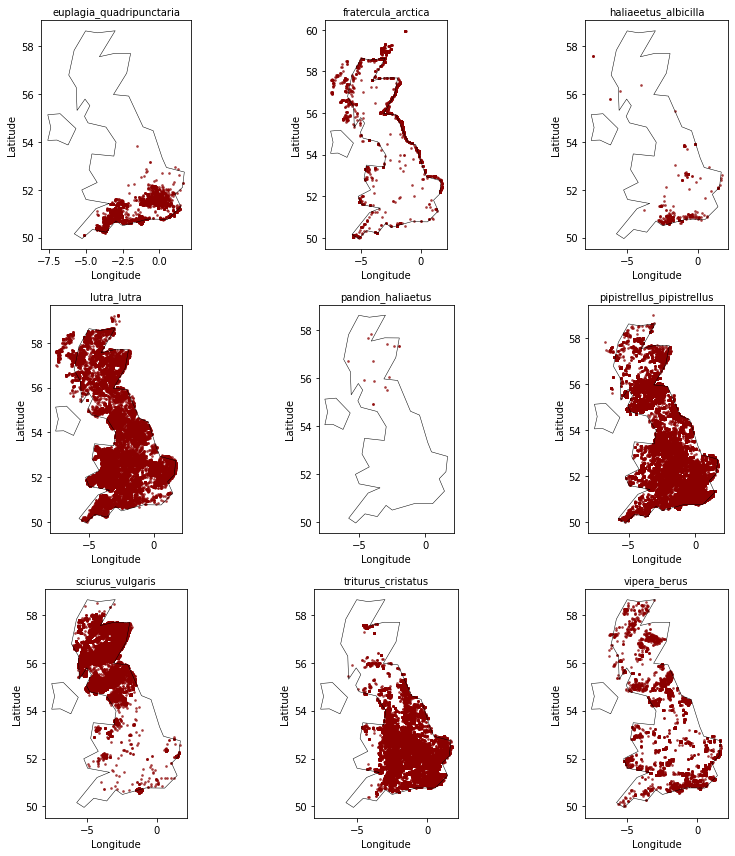

In [4]:
# ---------------------------------------------------------
# Explore data: Occurrence maps
# ---------------------------------------------------------

species_dfs = {
    'euplagia_quadripunctaria': euplagia_quadripunctaria,
    'fratercula_arctica': fratercula_arctica,
    'haliaeetus_albicilla': haliaeetus_albicilla,
    'lutra_lutra': lutra_lutra,
    'pandion_haliaetus': pandion_haliaetus,
    'pipistrellus_pipistrellus': pipistrellus_pipistrellus,
    'sciurus_vulgaris': sciurus_vulgaris,
    'triturus_cristatus': triturus_cristatus,
    'vipera_berus': vipera_berus
    }

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
uk = world[world['name'] == 'United Kingdom']

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax, (species, df) in zip(axes, species_dfs.items()):
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df['Longitude..WGS84.'], df['Latitude..WGS84.']),
        crs='EPSG:4326'
    )
    uk.boundary.plot(ax=ax, color='black', linewidth=0.5)
    gdf.plot(ax=ax, markersize=3, alpha=0.6, color='darkred')
    ax.set_title(species, fontsize=10)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

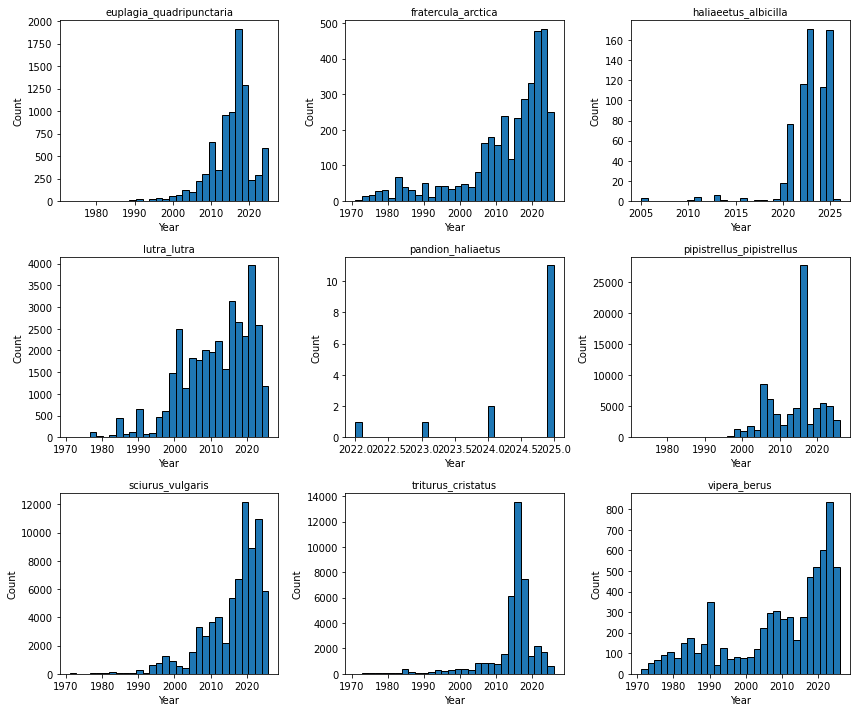

In [5]:
# ---------------------------------------------------------
# Explore data: Year histograms
# ---------------------------------------------------------

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for ax, (species, df) in zip(axes, species_dfs.items()):
    ax.hist(df['Year'].dropna(), bins=30, edgecolor='black')
    ax.set_title(species, fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()